# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [3]:
# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Display basic information
print(df.shape)
df.head()

(426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
# Summary of missing values
missing_values = df.isnull().mean().sort_values(ascending=False) * 100
missing_values.head(10)

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
dtype: float64

In [5]:

# Business Objective:
# Identify the major factors that influence used car prices
# and build a predictive model for estimating vehicle prices.

print(df.describe(include='all').T.head())

                 count unique       top   freq               mean  \
id            426880.0    NaN       NaN    NaN  7311486634.224333   
region          426880    404  columbus   3608                NaN   
price         426880.0    NaN       NaN    NaN       75199.033187   
year          425675.0    NaN       NaN    NaN        2011.235191   
manufacturer    409234     42      ford  70985                NaN   

                          std           min            25%           50%  \
id             4473170.412559  7207408119.0  7308143339.25  7312620821.0   
region                    NaN           NaN            NaN           NaN   
price         12182282.173598           0.0         5900.0       13950.0   
year                  9.45212        1900.0         2008.0        2013.0   
manufacturer              NaN           NaN            NaN           NaN   

                       75%           max  
id            7315253543.5  7317101084.0  
region                 NaN           NaN  

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [6]:

# Dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

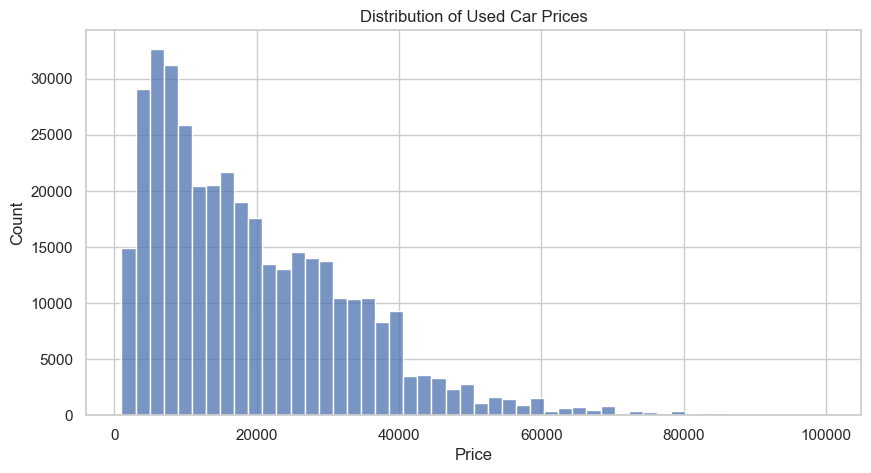

In [7]:
# Remove unrealistic prices and missing target values
df = df[(df['price'] > 1000) & (df['price'] < 100000)]

# Explore price distribution
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price')
plt.show()

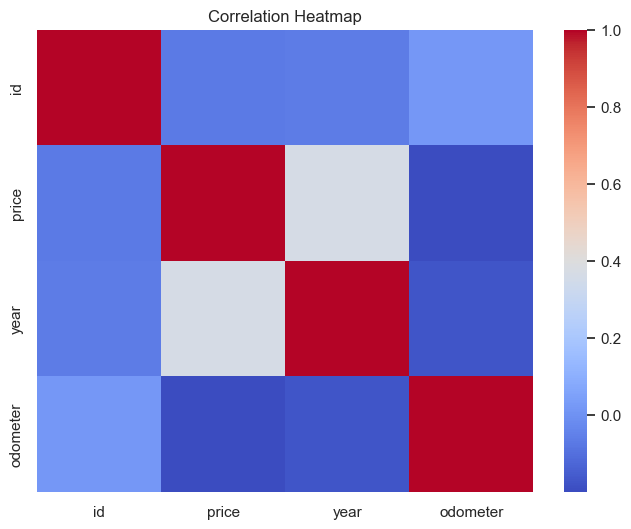

In [8]:
# Correlation for numerical features
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

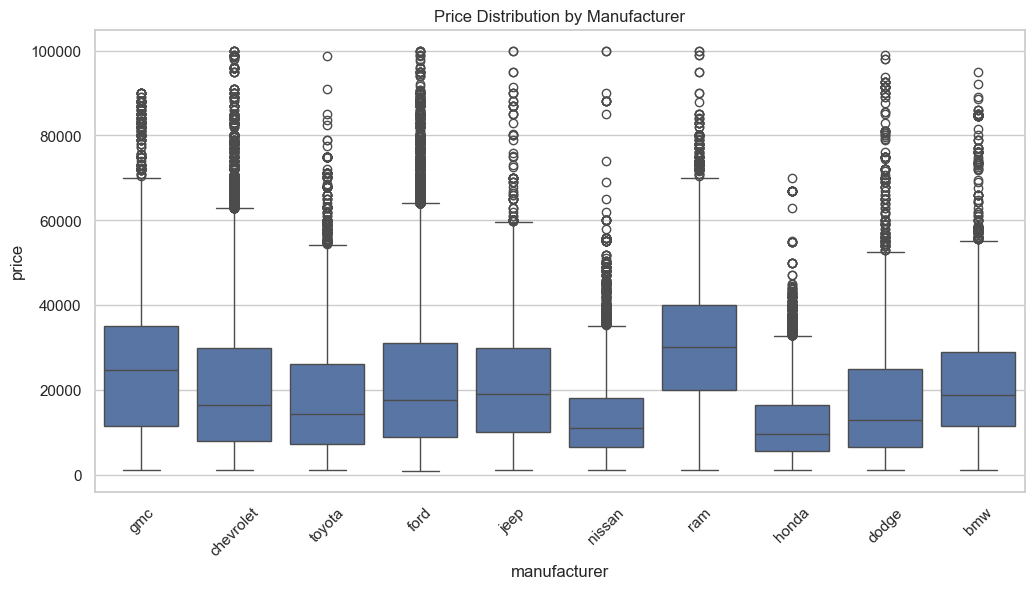

In [9]:

# Average price by manufacturer
top_makes = df['manufacturer'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['manufacturer'].isin(top_makes)],
            x='manufacturer',
            y='price')

plt.xticks(rotation=45)
plt.title('Price Distribution by Manufacturer')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [10]:
# Drop columns with excessive missing values or low predictive value
drop_cols = ['id', 'VIN', 'region']

df_model = df.drop(columns=drop_cols)

# Remove rows with missing critical values
df_model = df_model.dropna(subset=['year', 'manufacturer', 'fuel', 'odometer'])

df_model.shape

(359934, 15)

In [11]:

# Feature engineering
current_year = 2026
df_model['car_age'] = current_year - df_model['year']

# Keep selected features
features = [
    'manufacturer', 'condition', 'cylinders', 'fuel',
    'odometer', 'title_status', 'transmission',
    'drive', 'type', 'paint_color', 'state', 'car_age'
]

target = 'price'

X = df_model[features]
y = df_model[target]


In [13]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = X.select_dtypes(include=['object', 'string']).columns
numeric_features = X.select_dtypes(exclude=['object', 'string']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [14]:
# Final prepared datasets
print(X_train.shape)
print(X_test.shape)

(287947, 12)
(71987, 12)


In [15]:
# Data preparation summary
print("Prepared dataset successfully for modeling.")

Prepared dataset successfully for modeling.


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [16]:

# Baseline Linear Regression model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))


Linear Regression Results
MAE: 7058.872619441442
RMSE: 10170.850630387018
R2: 0.485636202503237


In [17]:
# Ridge Regression with cross-validation
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.1, 1.0, 10.0]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=3,
    scoring='neg_mean_absolute_error'
)

ridge_grid.fit(X_train, y_train)

ridge_pred = ridge_grid.predict(X_test)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Ridge R2:", r2_score(y_test, ridge_pred))

Best Ridge Parameters: {'model__alpha': 0.1}
Ridge MAE: 7058.649619968844
Ridge RMSE: 10169.625132668254
Ridge R2: 0.4857601476298439


In [18]:

# Random Forest model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))


Random Forest Results
MAE: 3635.3717690037347
RMSE: 5730.273216892307
R2: 0.8367299595694673


In [19]:

# Cross-validation scores
cv_scores = cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv=3,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())


Cross Validation R2 Scores: [0.4877388  0.4917633  0.48313795]
Average CV R2: 0.4875466806769298


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [20]:

# Compare model performance
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, rf_pred)
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, rf_pred)
    ]
})

results


,Model,R2 Score,MAE
0,Linear Regression,0.485636,7058.872619
1,Ridge Regression,0.485760,7058.649620
2,Random Forest,0.836730,3635.371769


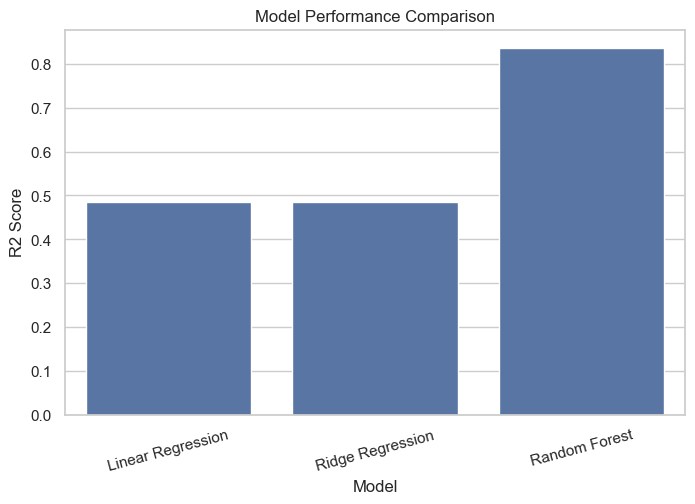

In [21]:

# Visual comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='R2 Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=15)
plt.show()


In [22]:

# Interpretation of findings

print('''
Key findings:
1. Vehicle age and odometer reading strongly influence used car prices.
2. Manufacturer and fuel type also impact resale value.
3. Random Forest performed better than linear models due to nonlinear relationships.
''')



Key findings:
1. Vehicle age and odometer reading strongly influence used car prices.
2. Manufacturer and fuel type also impact resale value.
3. Random Forest performed better than linear models due to nonlinear relationships.



In [23]:

# Evaluation metric rationale

print('''
R2 Score measures how well the model explains variation in price.
MAE provides an interpretable average prediction error in dollars.
RMSE penalizes large prediction errors more heavily.
''')



R2 Score measures how well the model explains variation in price.
MAE provides an interpretable average prediction error in dollars.
RMSE penalizes large prediction errors more heavily.



In [24]:

# Feature importance from Random Forest
rf_model = rf_pipeline.named_steps['model']

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [25]:

# Final evaluation summary
results.sort_values(by='R2 Score', ascending=False)


,Model,R2 Score,MAE
2,Random Forest,0.836730,3635.371769
1,Ridge Regression,0.485760,7058.649620
0,Linear Regression,0.485636,7058.872619


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [26]:

# Business recommendations

print('''
Recommendations:
- Focus on lower mileage and newer vehicles to maximize resale value.
- Premium manufacturers maintain stronger resale value.
- Dealerships can use pricing models to improve listing strategies.
''')



Recommendations:
- Focus on lower mileage and newer vehicles to maximize resale value.
- Premium manufacturers maintain stronger resale value.
- Dealerships can use pricing models to improve listing strategies.



In [27]:

# Next steps

print('''
Potential next steps:
1. Add additional features such as accident history.
2. Use advanced boosting models such as XGBoost or LightGBM.
3. Deploy the model using a web application or API.
''')



Potential next steps:
1. Add additional features such as accident history.
2. Use advanced boosting models such as XGBoost or LightGBM.
3. Deploy the model using a web application or API.



In [ ]:

# Save the best model if needed
import joblib

joblib.dump(rf_pipeline, 'used_car_price_model.pkl')

print("Model saved successfully.")


In [28]:

# README style project summary
summary = '''
Project Summary:
This project explored the factors affecting used car prices.
Multiple regression models were developed and evaluated.
Random Forest achieved the strongest predictive performance.
'''

print(summary)



Project Summary:
This project explored the factors affecting used car prices.
Multiple regression models were developed and evaluated.
Random Forest achieved the strongest predictive performance.



In [29]:

# Notebook conclusion

print('''
Conclusion:
Used car pricing depends heavily on vehicle age, mileage,
manufacturer, and transmission characteristics.
Machine learning models can support better pricing decisions.
''')



Conclusion:
Used car pricing depends heavily on vehicle age, mileage,
manufacturer, and transmission characteristics.
Machine learning models can support better pricing decisions.



In [30]:

# Optional sample predictions
sample_predictions = rf_pipeline.predict(X_test.head(5))

pd.DataFrame({
    'Actual Price': y_test.head(5).values,
    'Predicted Price': sample_predictions
})


,Actual Price,Predicted Price
0,26990,30256.270077
1,18900,15343.505082
2,2000,4587.393133
3,49998,36925.519446
4,4595,4506.263552


In [31]:

# End of notebook
print("Analysis complete.")


Analysis complete.
